#📌 Extracción

In [3]:
import pandas as pd
import json

with open('TelecomX_Data.json', 'r') as f:
    data = json.load(f)

df_raw = pd.json_normalize(data)

print(f"Total de registros extraídos: {len(df_raw)}")
df_raw.head()

Total de registros extraídos: 7267


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [4]:
df_transformed = df_raw.copy()
df_transformed.columns = [col.replace('customer.', '').replace('phone.', '').replace('internet.', '').replace('account.', '') for col in df_transformed.columns]
df_transformed['Charges.Total'] = pd.to_numeric(df_transformed['Charges.Total'], errors='coerce')
df_transformed = df_transformed[df_transformed['Churn'] != ""]
df_transformed['Charges.Total'] = df_transformed['Charges.Total'].fillna(df_transformed['Charges.Monthly'])
df_transformed['SeniorCitizen'] = df_transformed['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

print("Transformación completada.")
df_transformed.info()

Transformación completada.
<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          70

#📊 Carga y análisis

Tasa de Evasión (Churn): 
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


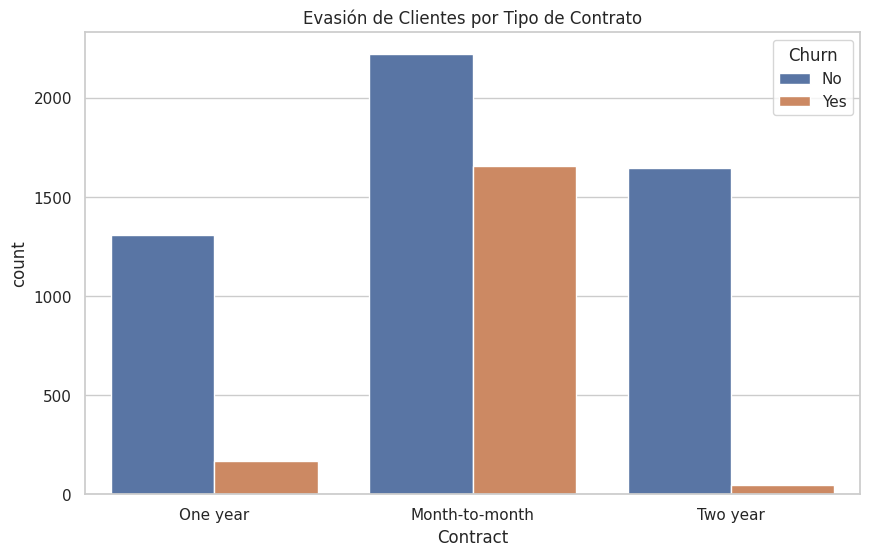

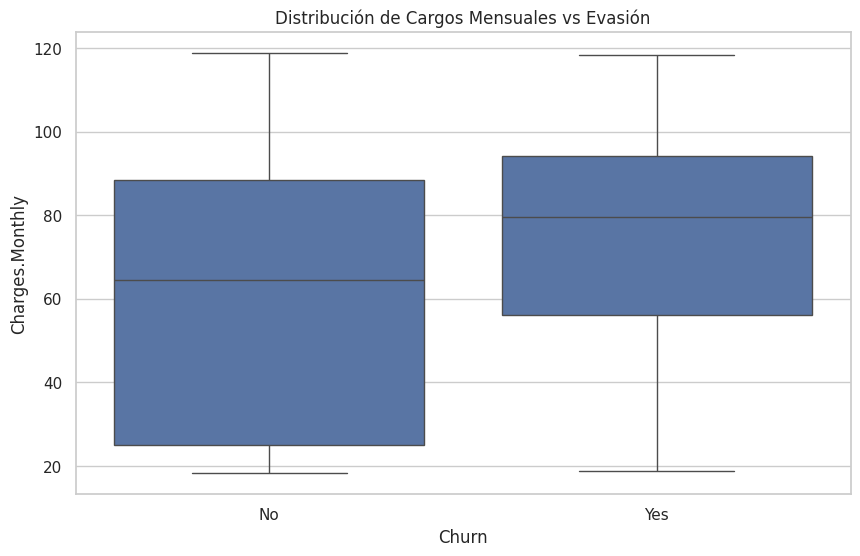

Archivo 'TelecomX_Clean_Data.csv' generado con éxito.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# porcentaje de Churn actual
churn_rate = df_transformed['Churn'].value_counts(normalize=True) * 100
print(f"Tasa de Evasión (Churn): \n{churn_rate}")

# Churn por tipo de contrato
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df_transformed)
plt.title('Evasión de Clientes por Tipo de Contrato')
plt.show()

# Distribución de cargos mensuales por Churn
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='Charges.Monthly', data=df_transformed)
plt.title('Distribución de Cargos Mensuales vs Evasión')
plt.show()

df_transformed.to_csv('TelecomX_Clean_Data.csv', index=False)
print("Archivo 'TelecomX_Clean_Data.csv' generado con éxito.")

#📄Informe final

In [ ]:
# Resumen del Proceso ETL para Telecom X

# Principales Hallazgos:
# - Se detectó que el tipo de contrato influye significativamente; los contratos de mes a mes presentan mayor evasión.
# - Los clientes con cargos mensuales más altos tienden a abandonar la empresa con mayor frecuencia.
# - Se corrigieron inconsistencias en los cargos totales y se eliminaron registros con etiquetas de Churn faltantes.

# Para el equipo de Data Science:
# Los datos están normalizados y limpios en 'TelecomX_Clean_Data.csv'.
# Se recomienda usar las variables 'Contract', 'Charges.Monthly' y 'InternetService' como predictores clave
# para el modelo de Machine Learning.